# The Anatomy of a Hit - Complete Analysis

**Project Goal**: Analyze how musical identity drifts over decades and what data reveals about cultural homogenization in hit songs.

**Core Question**: Are all hit songs starting to sound and say the same thing — and if so, when did it start?

## Phase 0: Data Collection Setup

In [2]:
# Install required packages
!pip3 install -r requirements.txt
!python3 -m spacy download en_core_web_sm

  Using cached billboard.py-7.1.0-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached joypy-0.2.6-py2.py3-none-any.whl.metadata (812 bytes)
  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached ipykernel-7.2.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.

In [4]:
!pip3 install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Step 1: Billboard Data Collection

Run the Billboard data collection to generate our master song list.

In [2]:
# Execute Phase 0 - Billboard data collection
%run Phase_0_Billboard_Data.ipynb

Libraries imported successfully
Normalization functions defined
Billboard collection function defined
Starting Billboard data collection...



Collected 5053 songs total
Years covered: 1970 - 2023
Before deduplication: 5053 songs
After deduplication: 3362 unique songs

Sample of the data:
                              title             artist  year  chart_position  \
0        bridge over troubled water  simon & garfunkel  1970               1   
1                      close to you         carpenters  1970               2   
2    american womanno sugar tonight      the guess who  1970               3   
3  raindrops keep fallin on my head        b.j. thomas  1970               4   
4                               war        edwin starr  1970               5   

   weeks_on_chart decade  top10  
0               1  1970s      1  
1               1  1970s      1  
2               1  1970s      1  
3               1  1970s      1  
4               1  1970s      1  
Songs by decade:
decade
1970s    796
1980s    866
1990s    189
2000s    269
2010s    888
2020s    354
Name: count, dtype: int64

Top 10 hits by decade:
decade
1970s   

## Step 2: Audio Features Collection

In [6]:
!pip3 install yt-dlp librosa


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 26.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [6]:
exec(open('spotify_audio_features.py').read())

Loaded 3362 songs from songs.csv
yt-dlp version: 2026.03.13
Loaded 2357 cached results
Processing 1005 remaining songs...


yt-dlp error for 'viva la vida': ERROR: [youtube] MY4eEOB1wSI: Sign in to confirm your age. This video may be inappropriate for some users. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dl


yt-dlp error for 'sober': ERROR: [youtube] 4Kk4xtkBalY: This video is not available



yt-dlp error for 'tonight': ERROR: [youtube] -yFj3FvoOWY: Sign in to confirm your age. This video may be inappropriate for some users. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dl


Checkpoint: 2364 saved, 10 processed


...

Checkpoint: 3329 saved, 980 processed


Checkpoint: 3339 saved, 990 processed


Checkpoint: 3349 saved, 1000 processed


yt-dlp error for 'bzrp music sessions vol 53': 

ERROR: ffmpeg exited with code 196



Logged 12 total failures
Before cleaning: 3353 songs
After cleaning: 3351 songs
Saved audio_clean.csv

Final results:
Successfully processed: 3351 songs
Failed: 1 songs
Success rate: 99.7%


## Step 3: Genius Lyrics Collection

**⚠️ Important**: You need to set up Genius API credentials first:
1. Go to https://genius.com/api-clients
2. Create a new API client
3. Get your Access Token
4. Set environment variables or modify the script

In [11]:
# Set your Genius credentials (replace with your actual credentials)
os.environ['GENIUS_ACCESS_TOKEN'] = '06cjAkkFfNOn0dBvoWQ3zzM04Jzv8zhI9du_MHXPvuwTqBS4ACwzM1pnL4URtCR6'

# Run Genius lyrics collection
exec(open('genius_lyrics_scraper.py').read())

Loaded 3362 songs from songs.csv
Loaded 3287 cached lyrics
Processing 75 remaining songs...


Validation failed for rocket man by elton john: Lyrics too short
Validation failed for rocket man by elton john: Lyrics too short
Validation failed for rocket man by elton john: Lyrics too short


Checkpoint: 3287 lyrics saved


Checkpoint: 3287 lyrics saved


Checkpoint: 3287 lyrics saved


...

Validation failed for lemon by n*e*r*d & rihanna: Contains non-lyric content: composer
Validation failed for lemon by n*e*r*d & rihanna: Contains non-lyric content: composer
Validation failed for lemon by n*e*r*d & rihanna: Contains non-lyric content: composer


Validation failed for me by taylor swift featuring brendon urie: Lyrics too short
Validation failed for me by taylor swift featuring brendon urie: Lyrics too short
Validation failed for me by taylor swift featuring brendon urie: Lyrics too short


Checkpoint: 3288 lyrics saved


Checkpoint: 3288 lyrics saved


Logged 149 total failures
\nFinal results:
Successfully processed: 3288 songs
Failed: 0 songs
Success rate: 97.8%
\nLyrics statistics:
Average word count: 390.4
Average lexical diversity: 0.361


## Step 4: Audio Feature Analysis

Loaded 3351 songs with audio features
Decades covered: 1970s, 1980s, 1990s, 2000s, 2010s, 2020s
Starting Audio Feature Analysis...
\n1. Creating feature distribution plots...


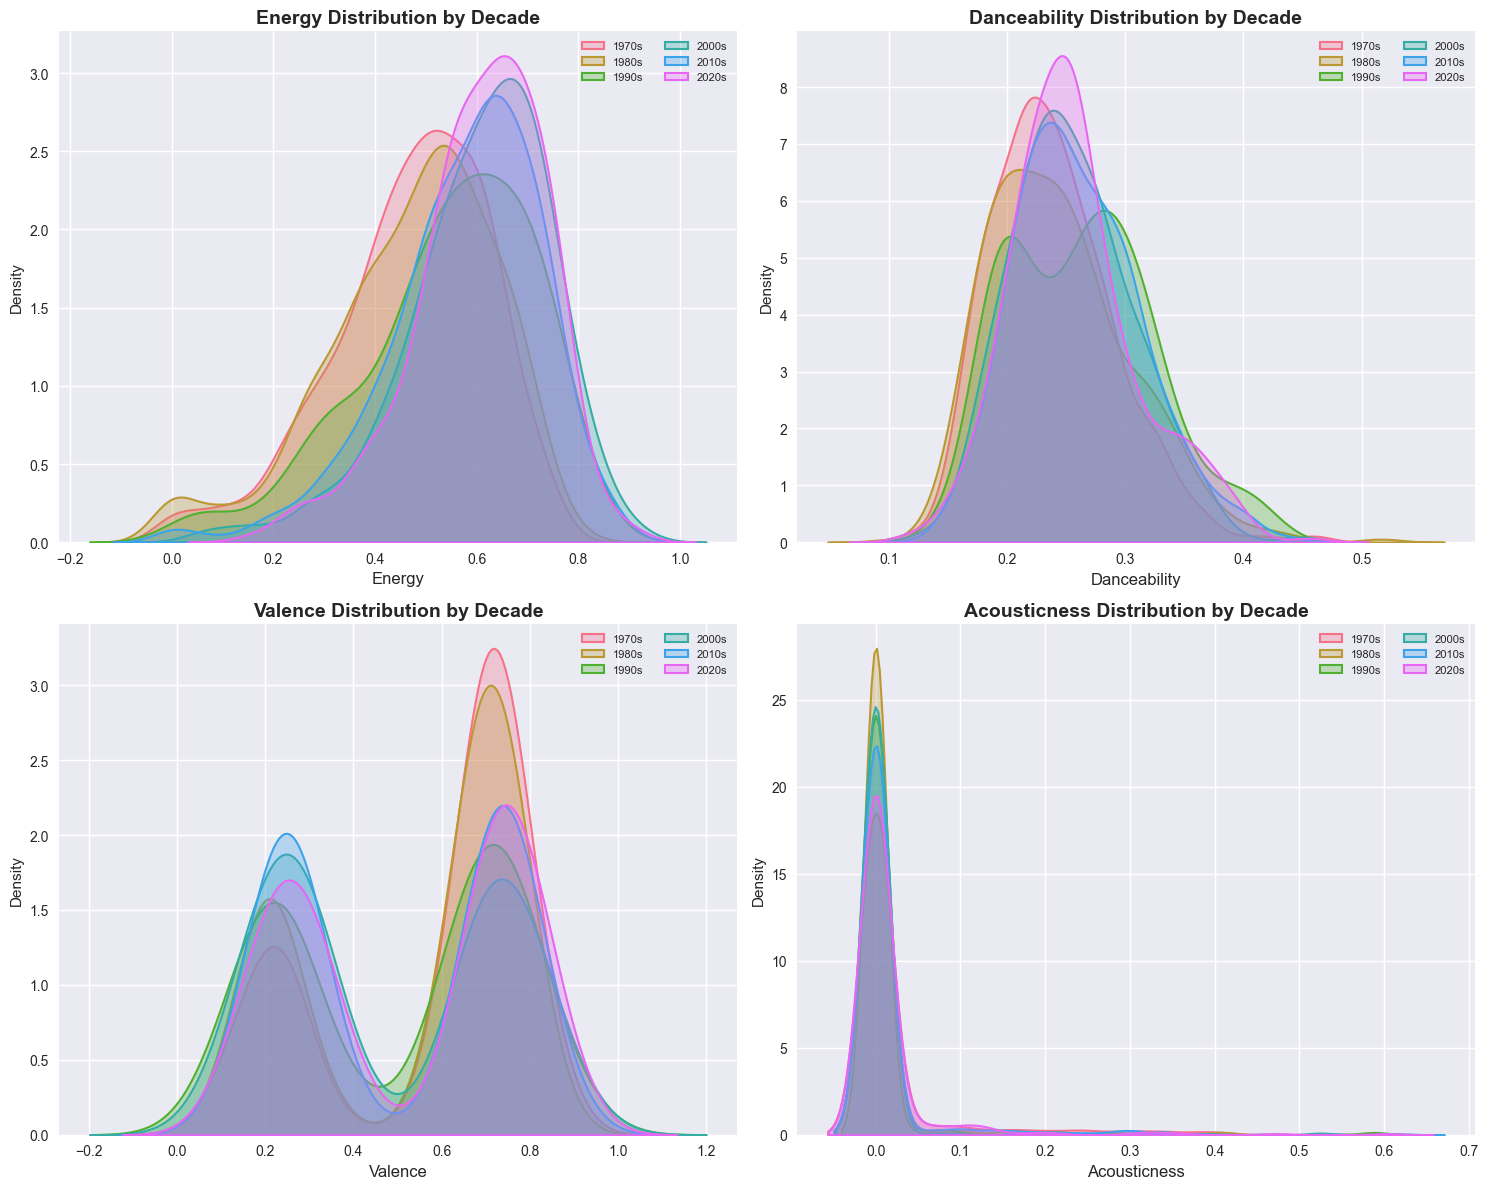

\n2. Analyzing feature trends over time...


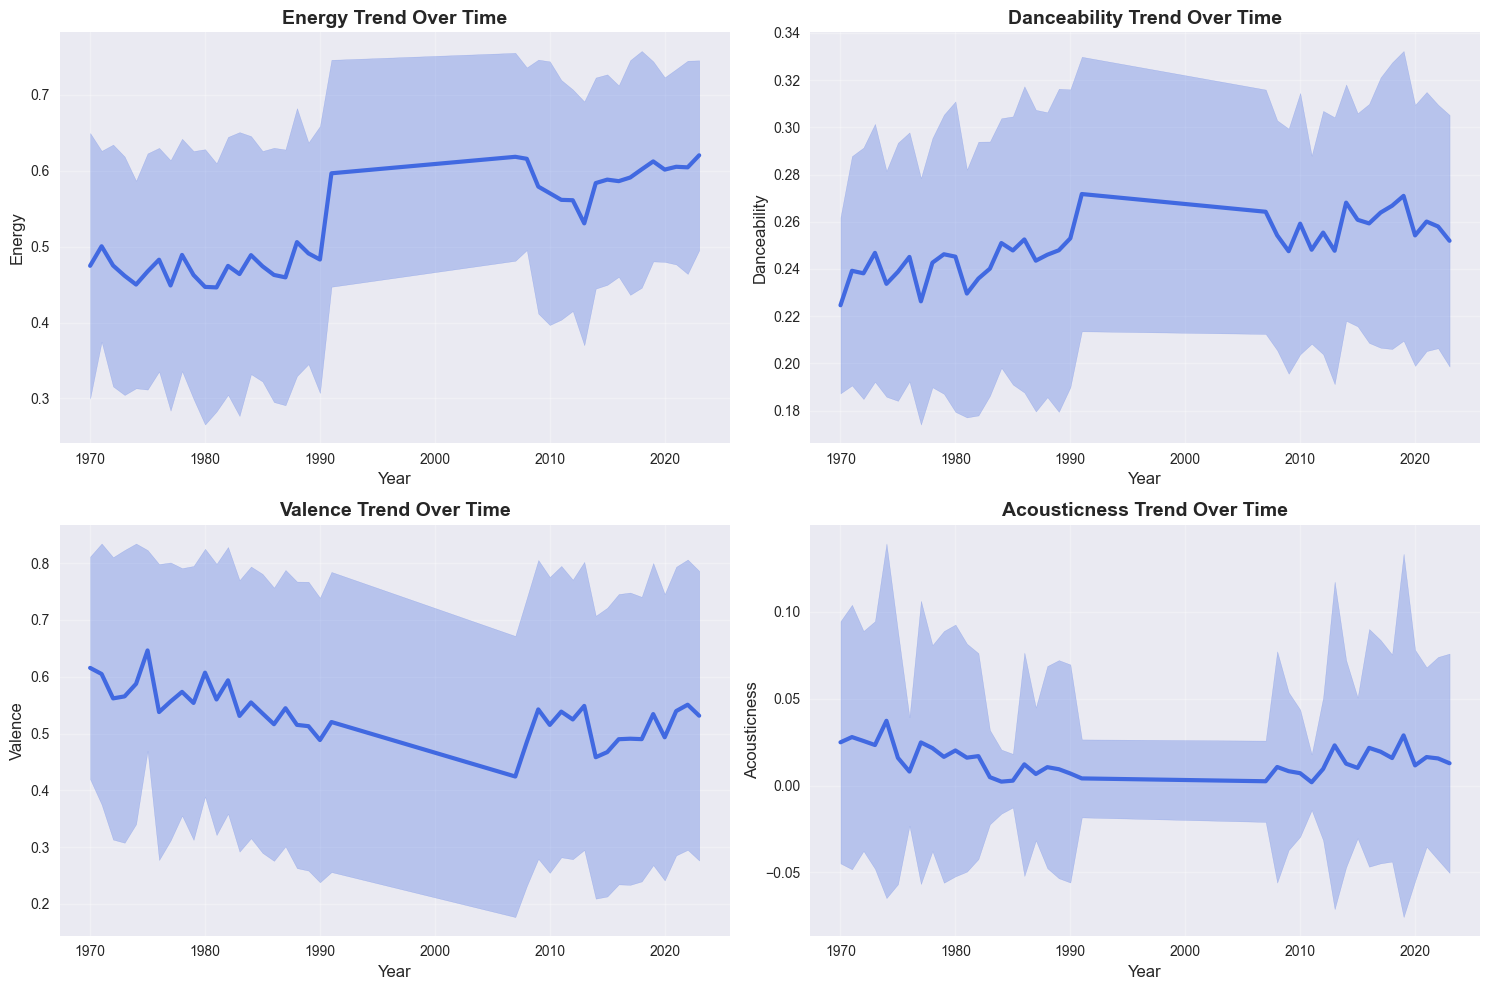

\n3. Creating correlation heatmap...


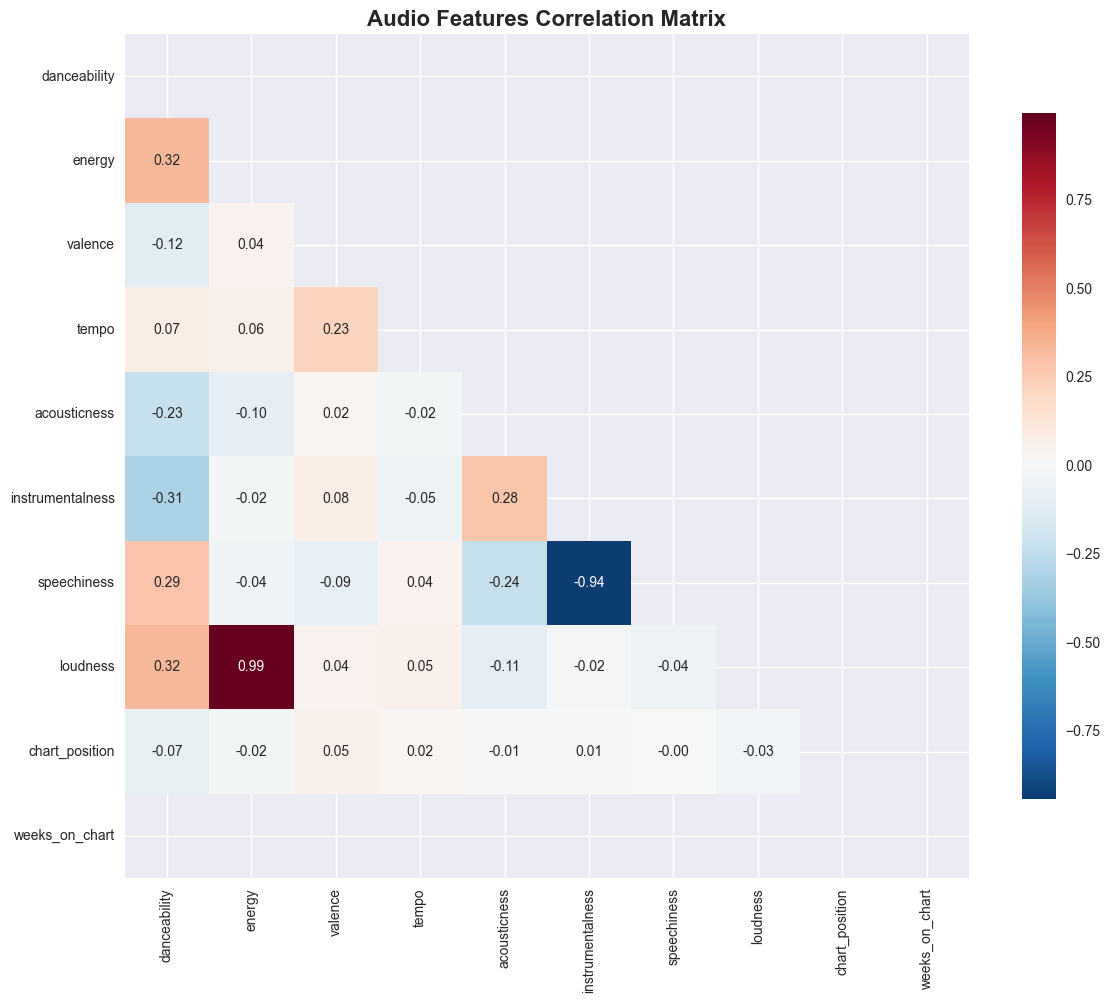

\n4. Performing PCA analysis...


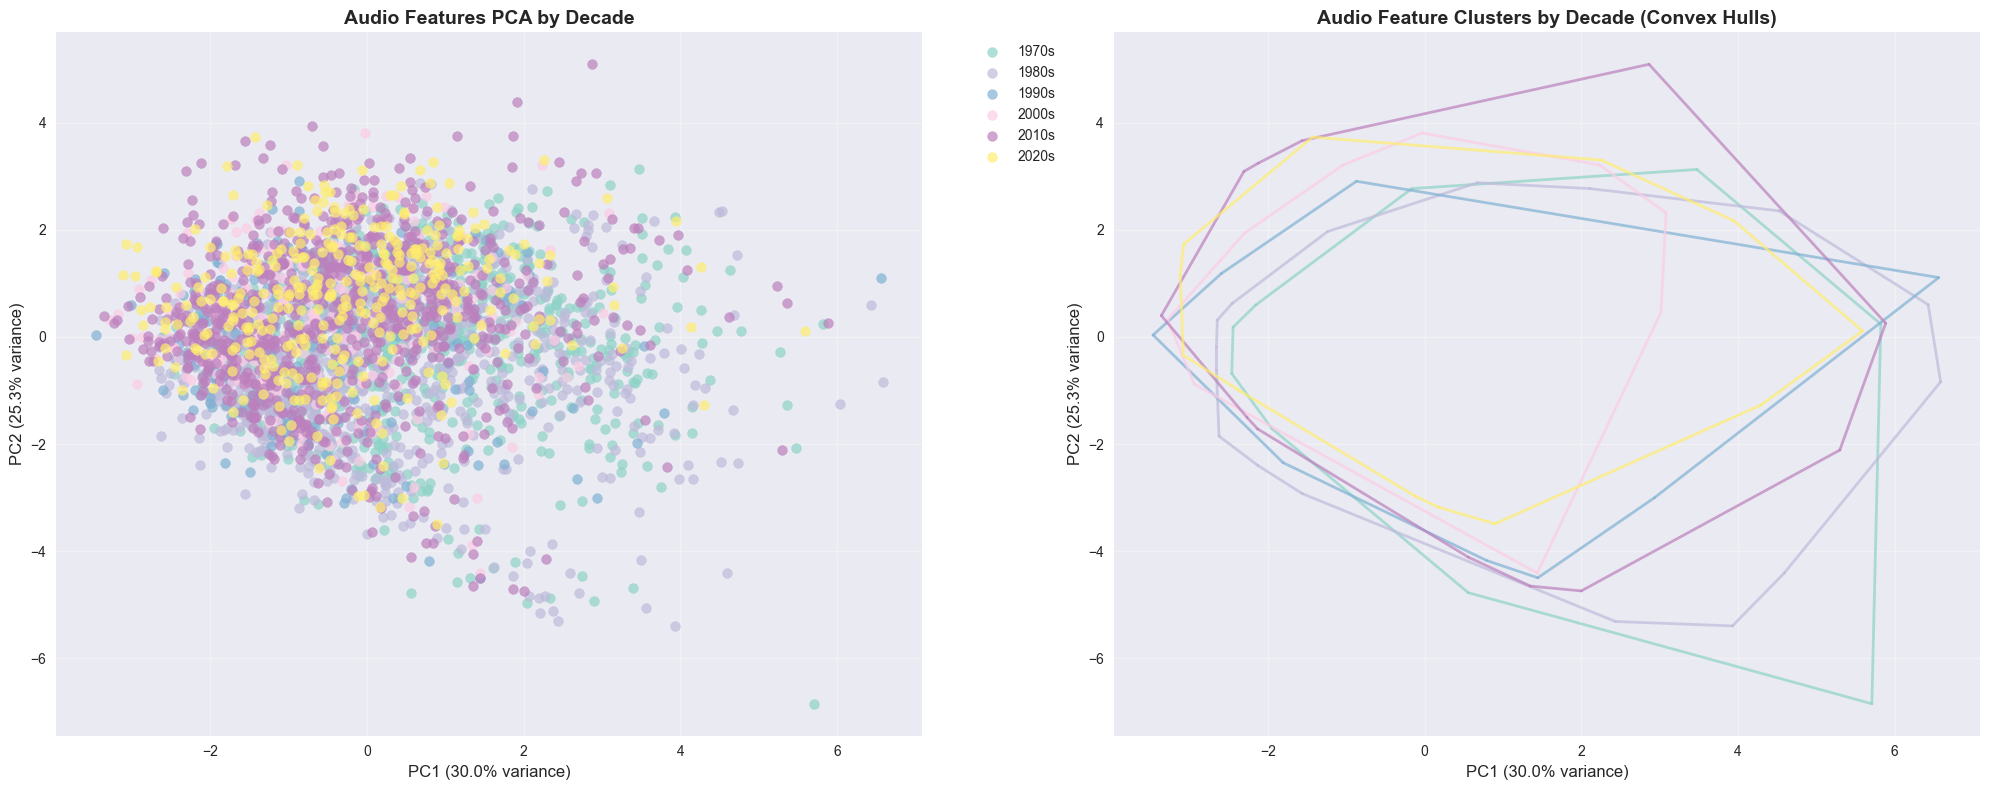

Cluster Areas (smaller = more converged):
1970s: 57.160
1980s: 54.844
1990s: 41.192
2000s: 32.865
2010s: 58.804
2020s: 41.064
\n5. Analyzing feature importance...


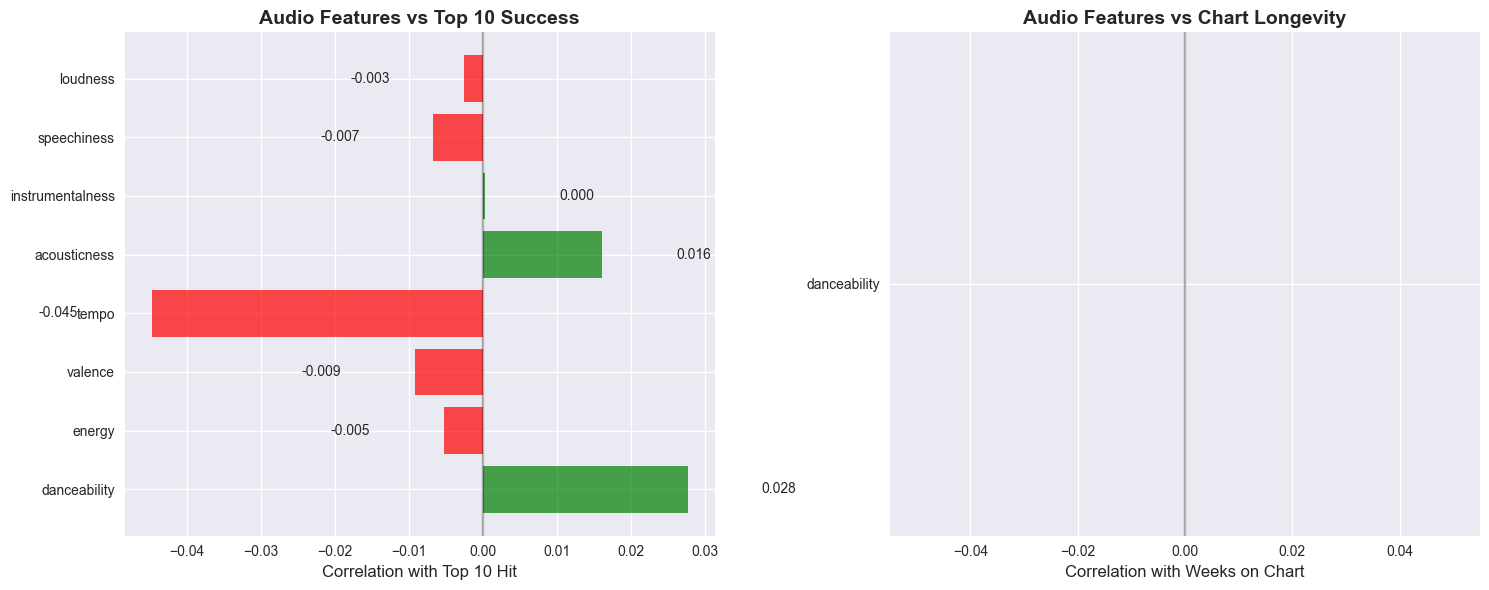

\nAnalysis complete! Check the generated PNG files.
\nKey findings:
- Audio feature distributions show clear patterns by decade
- PCA reveals clustering patterns that may indicate convergence
- Certain audio features correlate more strongly with chart success


In [16]:
# Run audio analysis
exec(open('audio_analysis.py').read())

## Step 5: NLP Lyrics Analysis

Loaded 3288 songs with lyrics
Decades covered: 1970s, 1980s, 1990s, 2000s, 2010s, 2020s
Starting NLP Lyrics Analysis...
\n1. Analyzing lexical diversity trends...


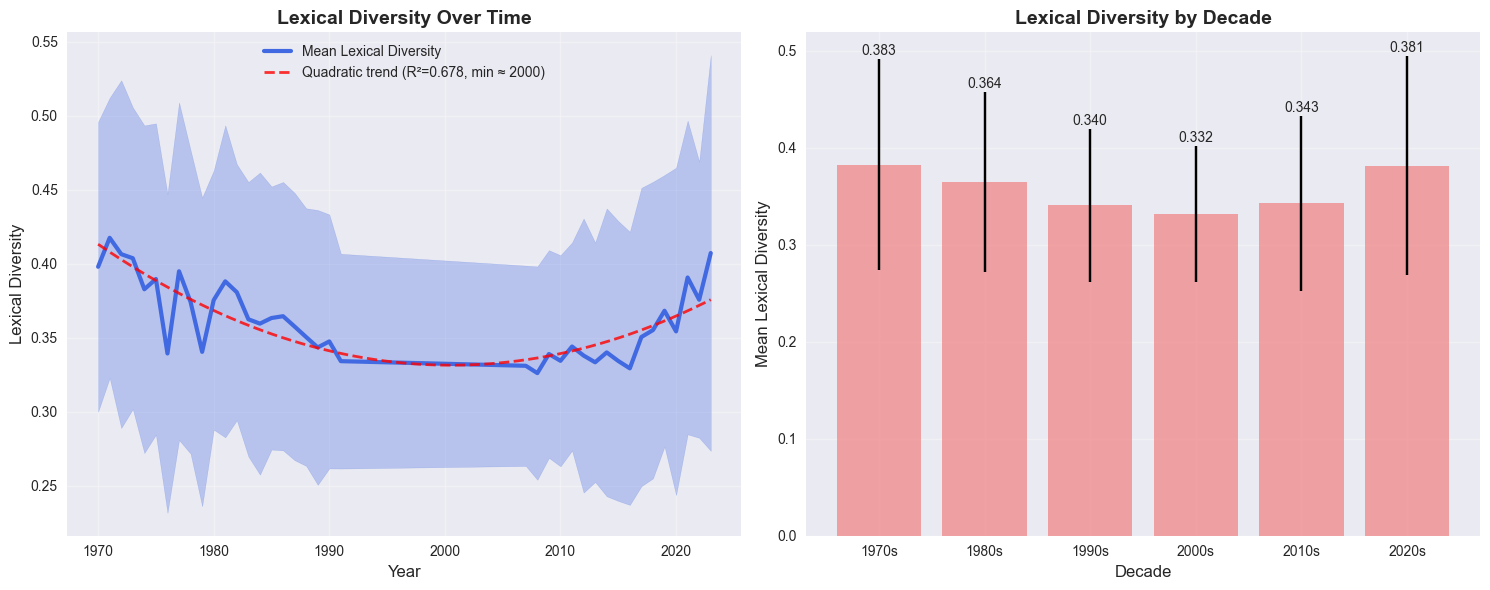

\n2. Analyzing sentiment patterns...


Analyzing sentiment: 100%|██████████| 3288/3288 [00:04<00:00, 698.67it/s]


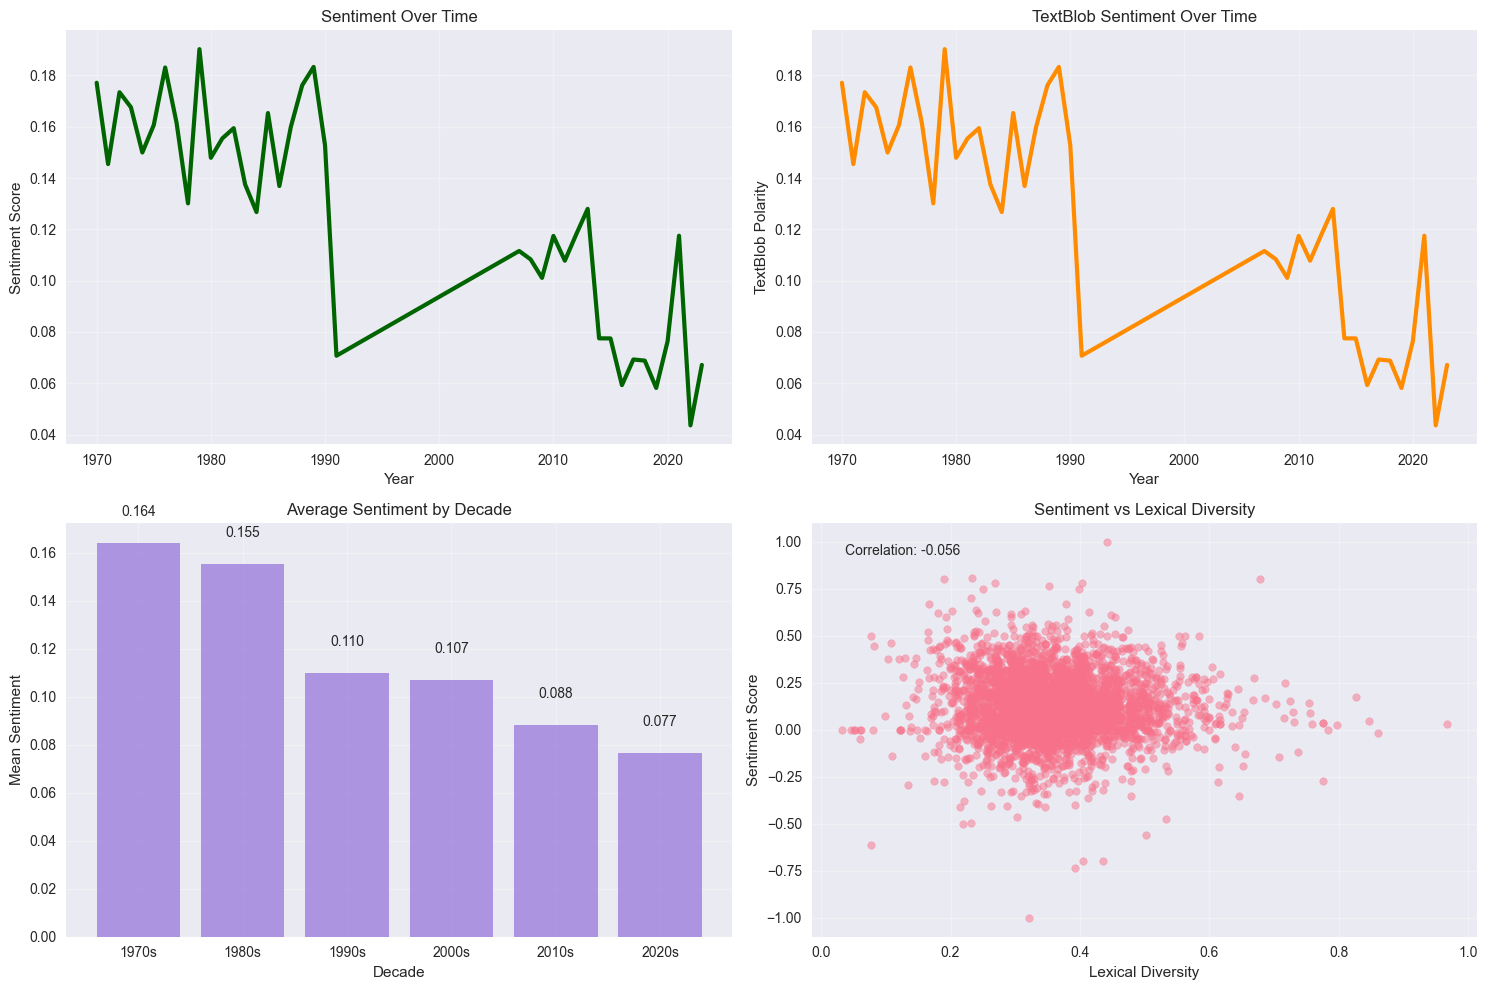

\n3. Analyzing vocabulary drift...


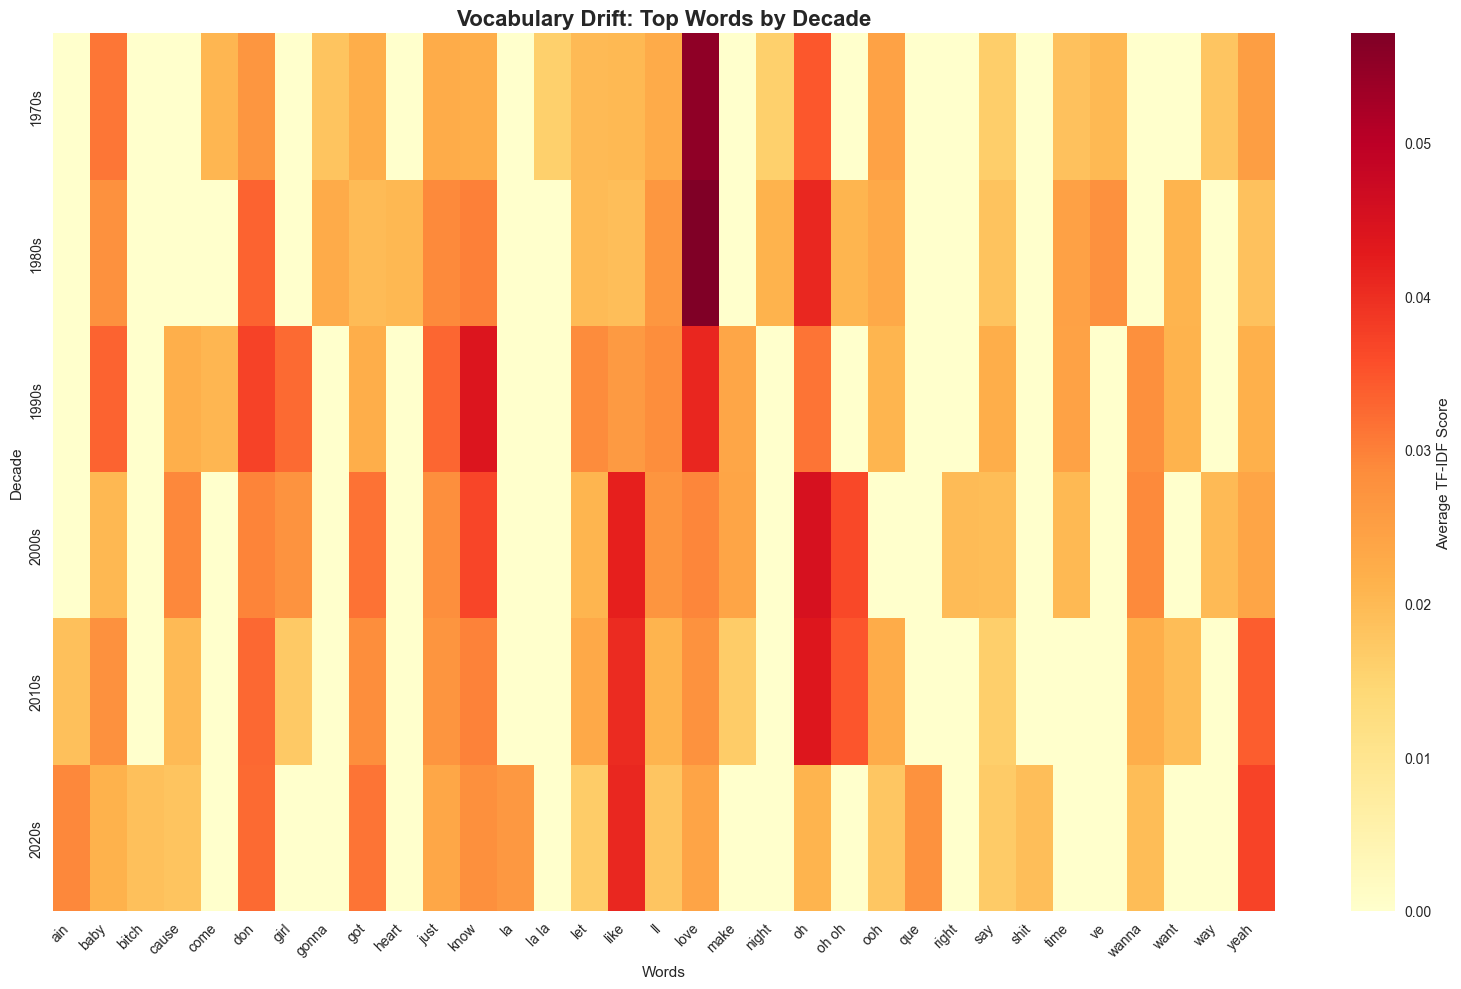

\n4. Performing lyrical clustering...
\n5. Creating UMAP visualization...


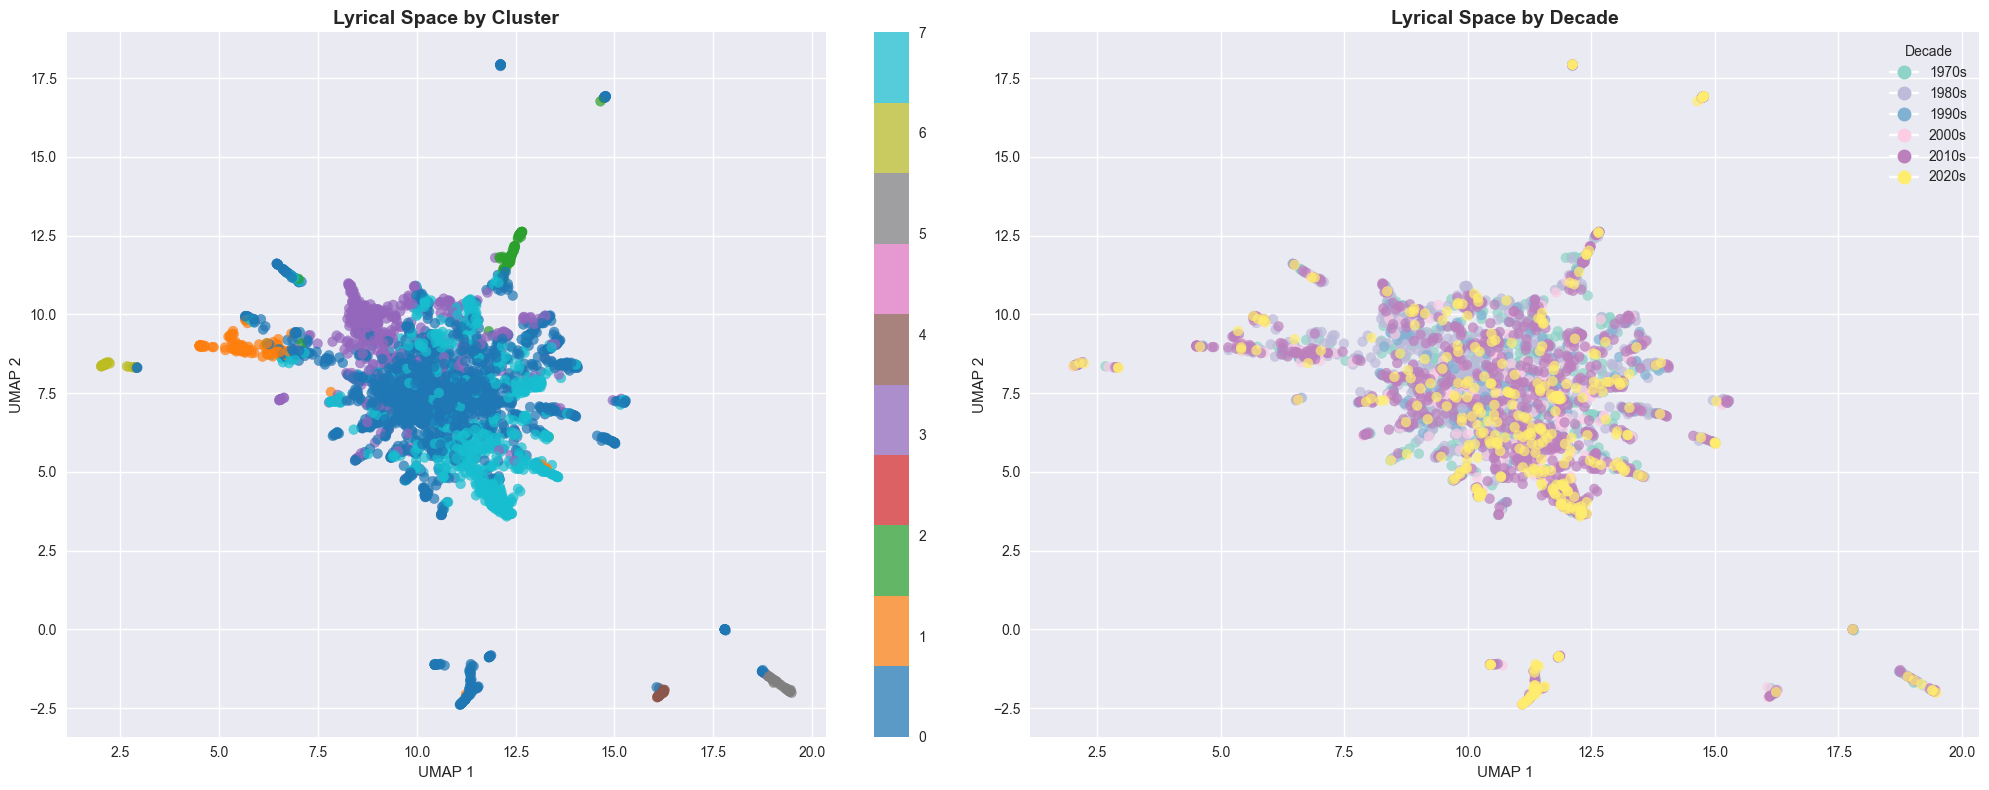

\n6. Running LDA topic modeling...


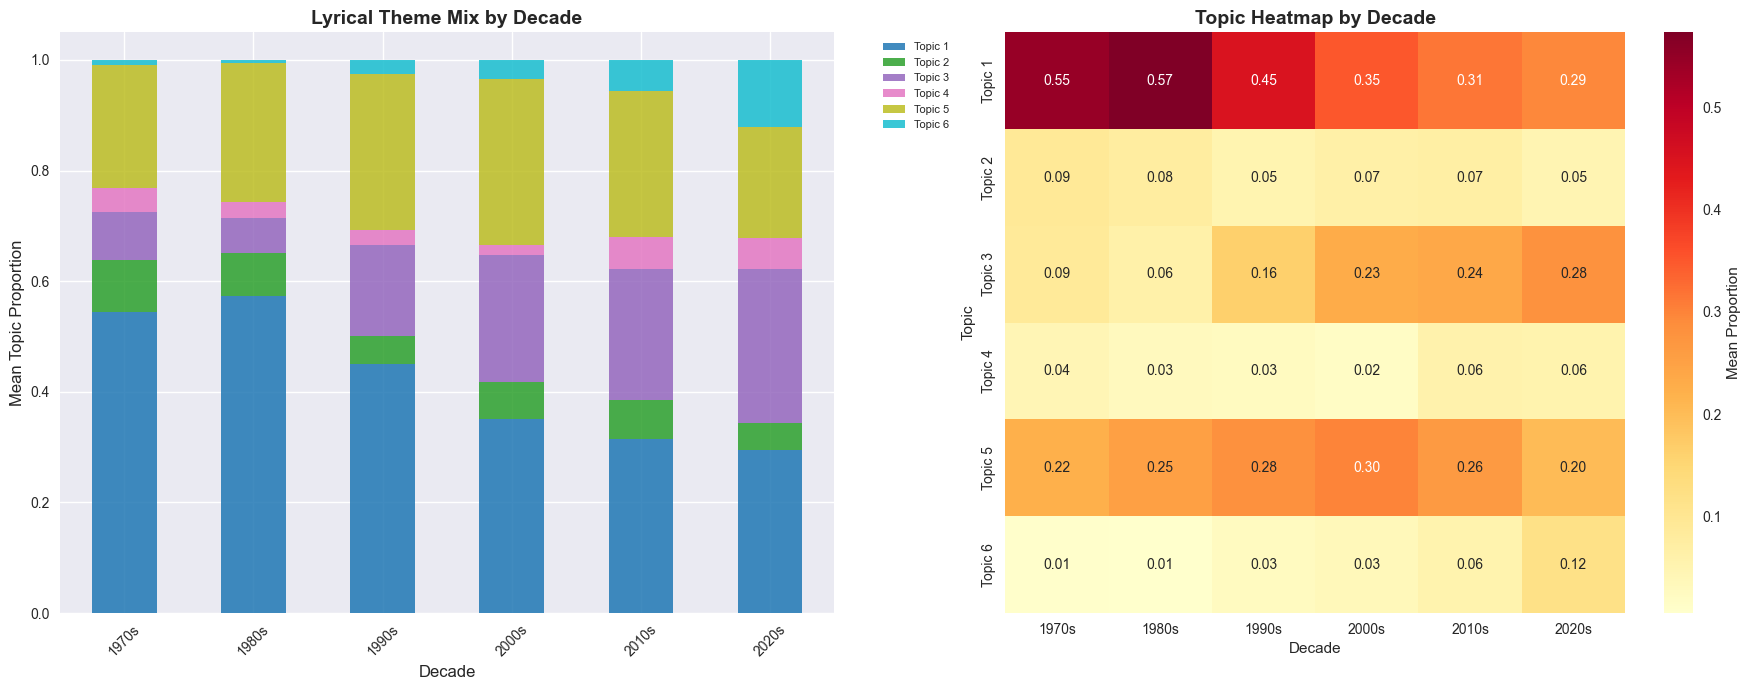


Top words per topic:
  Topic 1: love, know, ll, don
  Topic 2: oh, la, na, dance
  Topic 3: like, got, ain, yeah
  Topic 4: ooh, da, ah, doo
  Topic 5: baby, yeah, don, wanna
  Topic 6: que, la, en, lo
\n7. Running Word2Vec semantic drift...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


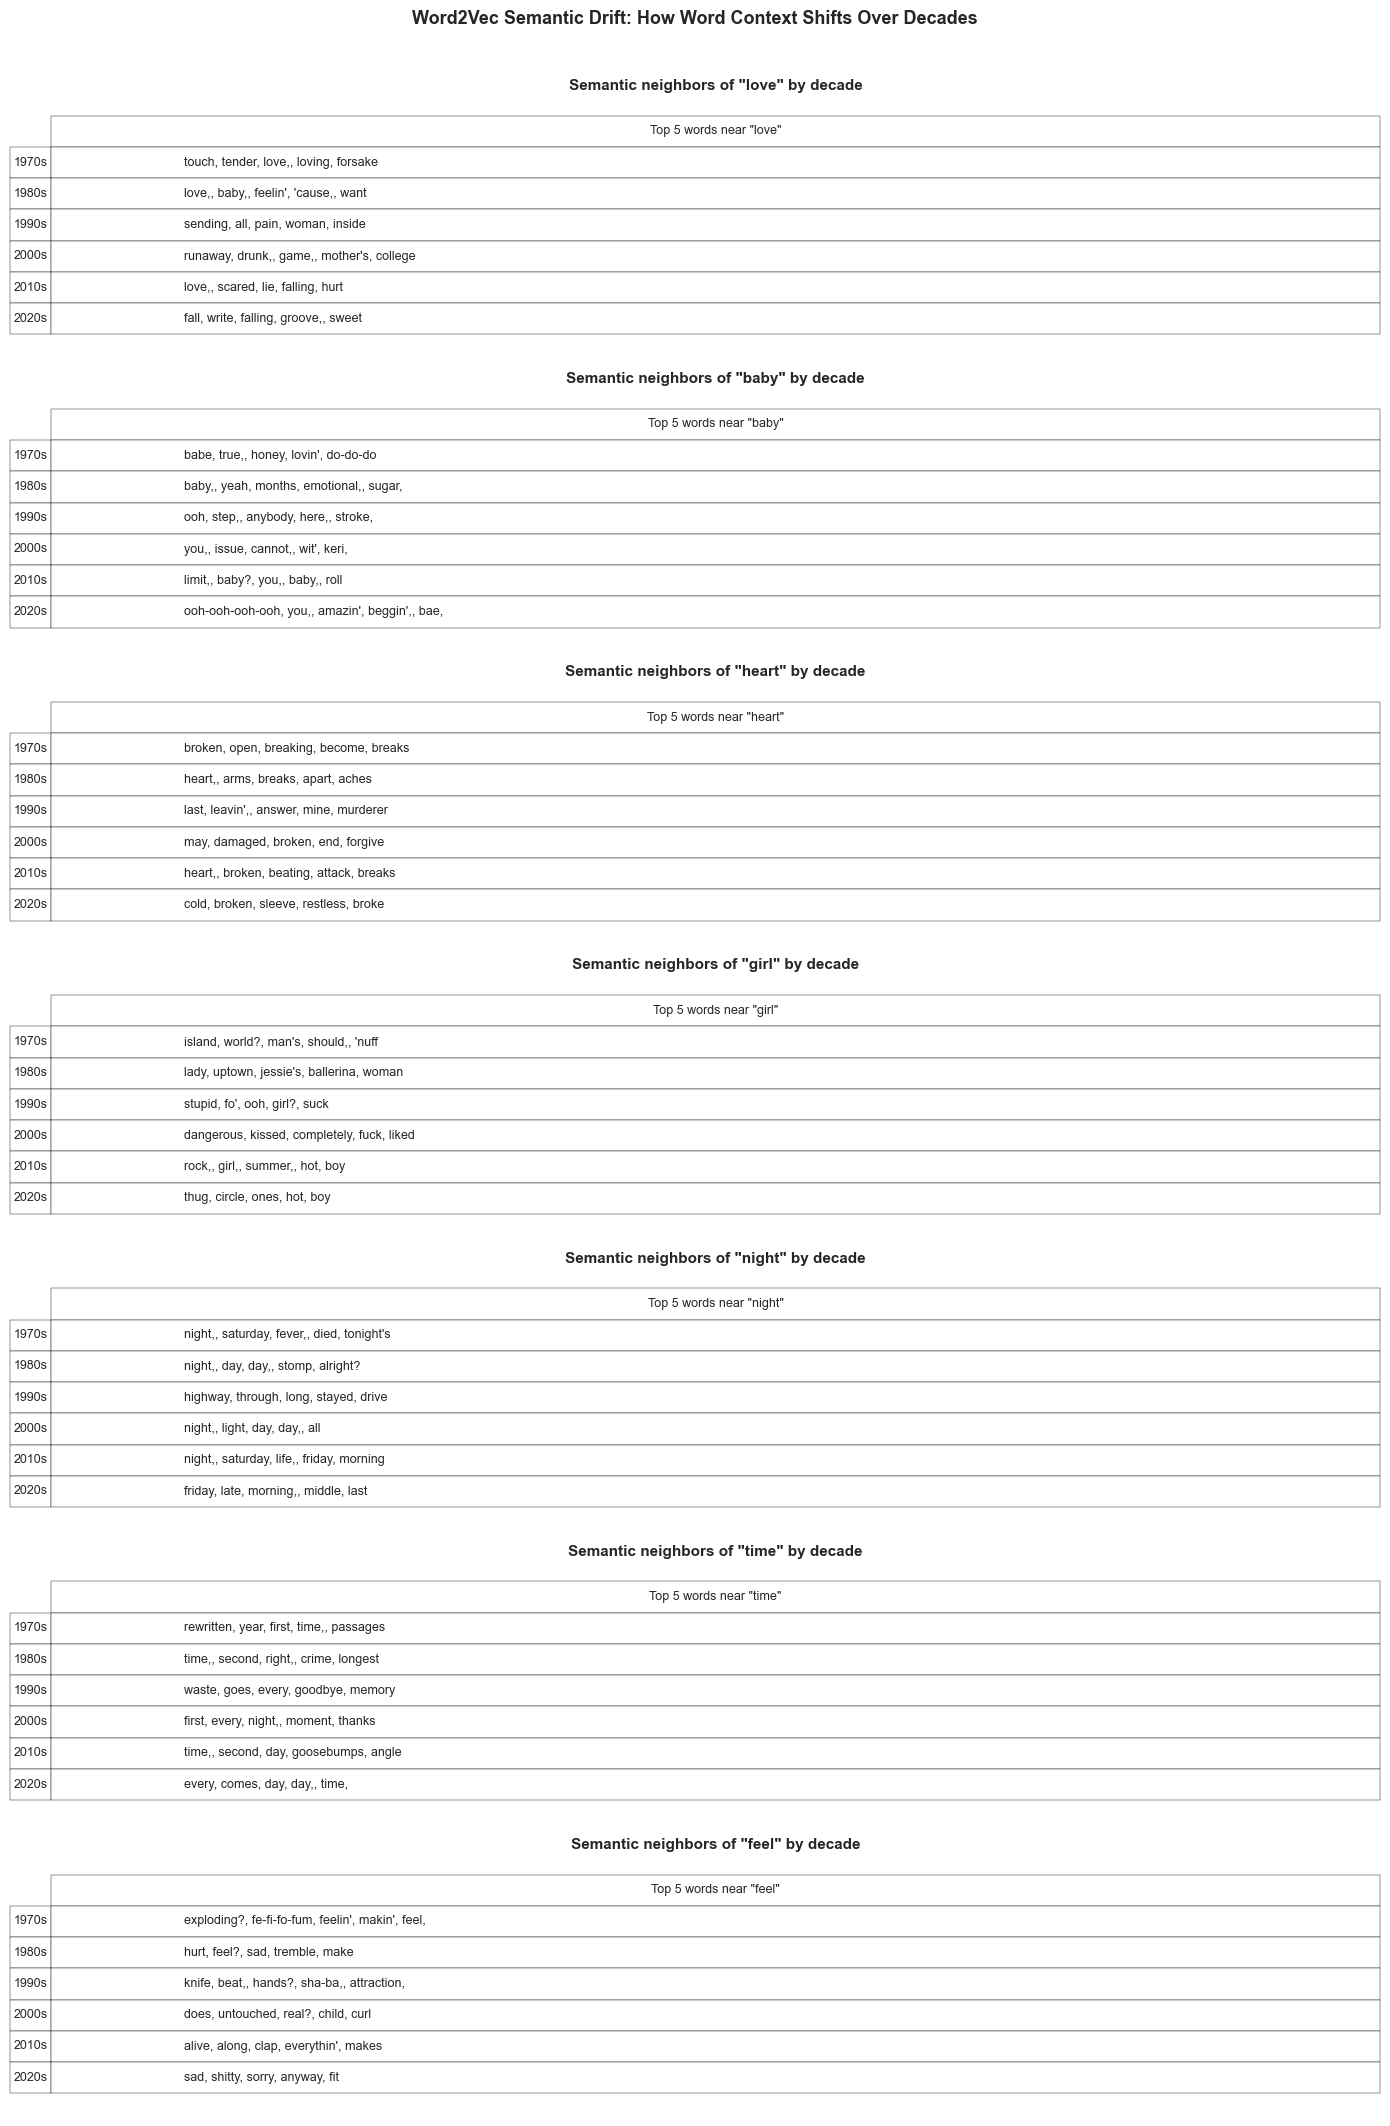

\nAnalysis complete! Check the generated PNG files.
\nLyrical Clusters Summary:
Cluster 0: 1818 songs
  Top words: know, just, ll, don, oh
  Dominant decade: 1980s
Cluster 1: 123 songs
  Top words: woah oh, love, woah, oh, oh oh
  Dominant decade: 2010s
Cluster 2: 74 songs
  Top words: baby, love, oh, ooh, ooh ooh
  Dominant decade: 2010s
Cluster 3: 475 songs
  Top words: ll, know, love love, baby, love
  Dominant decade: 1980s
Cluster 4: 26 songs
  Top words: da la, la, la da, da da, da
  Dominant decade: 1970s
Cluster 5: 51 songs
  Top words: ooh, oh, love, la, la la
  Dominant decade: 1970s
Cluster 6: 34 songs
  Top words: ain ain, oh na, oh, na na, na
  Dominant decade: 2010s
Cluster 7: 687 songs
  Top words: baby, got, don, like, yeah
  Dominant decade: 2010s
\nKey findings:
- Lexical diversity shows clear trends over decades
- Sentiment patterns reveal emotional shifts in popular music
- Vocabulary drift highlights cultural changes
- Lyrical clusters reveal patterns beyond tradit

In [35]:
# Run NLP analysis
exec(open('nlp_analysis.py').read())

## Step 6: Merge Datasets

Audio dataset: 3351 songs
Lyrics dataset: 3288 songs
\nMerging audio and lyrics datasets...
Merged dataset: 3278 songs
Merge success rate: 97.8%
Final clean dataset: 3278 songs
Years covered: 1970 - 2023
Decades: 1970s, 1980s, 1990s, 2000s, 2010s, 2020s
\nCreating machine learning features...
\nAnalyzing feature distributions...


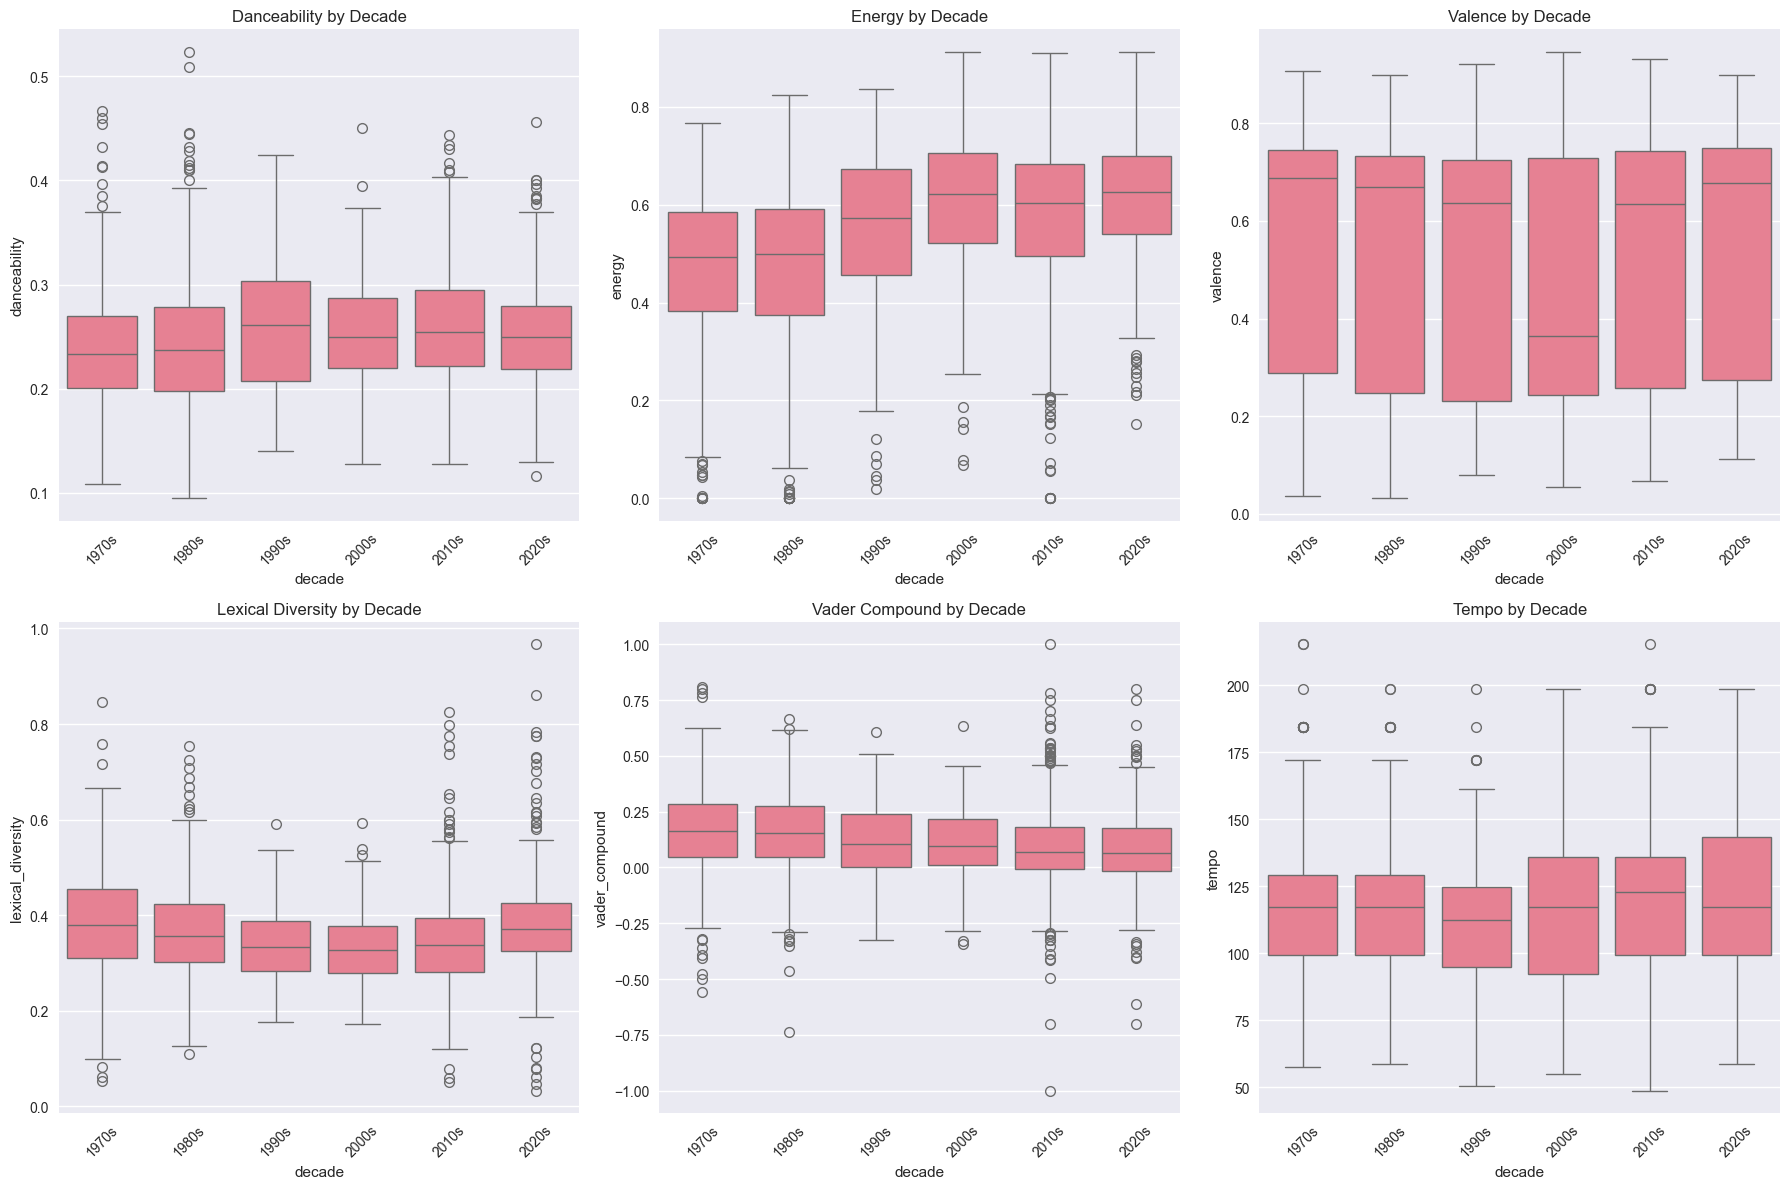

Saved merged dataset to merged.csv
Dataset summary saved to dataset_summary.txt
Saved ML features to ml_features.csv
\nMerge complete! Ready for combined analysis and modeling.


In [25]:
# Merge audio and lyrics datasets
exec(open('merge_datasets.py').read())

## Step 7: Final Combined Analysis

Loaded merged dataset: 3278 songs
Years: 1970 - 2023
Top 10 hits: 320 (9.8%)
Starting Final Combined Analysis...
\n1. Training predictive models...
\nTraining Random Forest...
  Accuracy: 0.902
  F1 Score: 0.000
  CV Score: 0.902 ± 0.001
\nTraining KNN...
  Accuracy: 0.898
  F1 Score: 0.000
  CV Score: 0.901 ± 0.002
\nTraining Logistic Regression...
  Accuracy: 0.902
  F1 Score: 0.000
  CV Score: 0.902 ± 0.001
\n2. SHAP analysis...
Computing SHAP values (this may take a minute)...


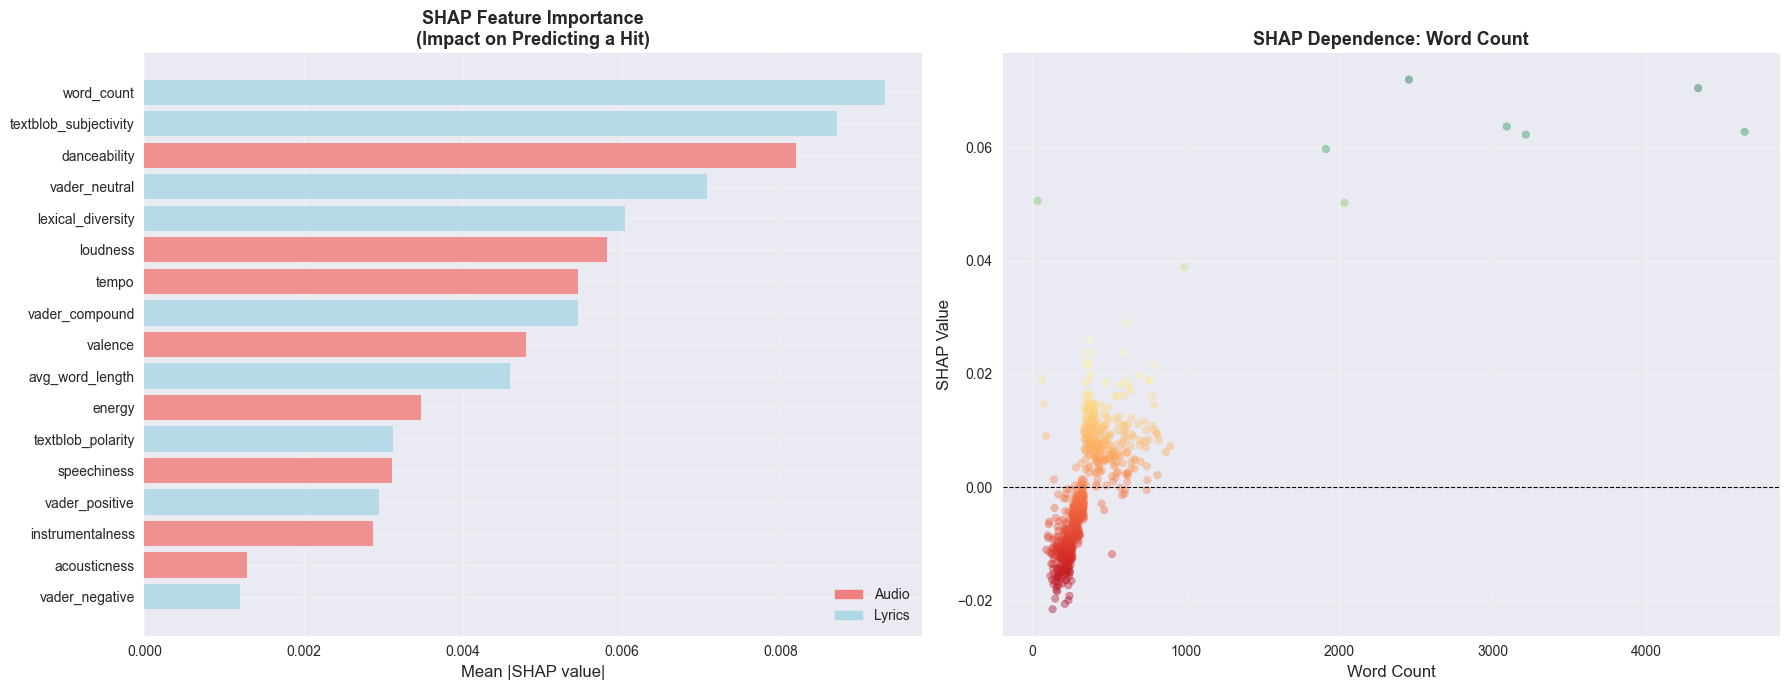

\n3. Analyzing feature importance...


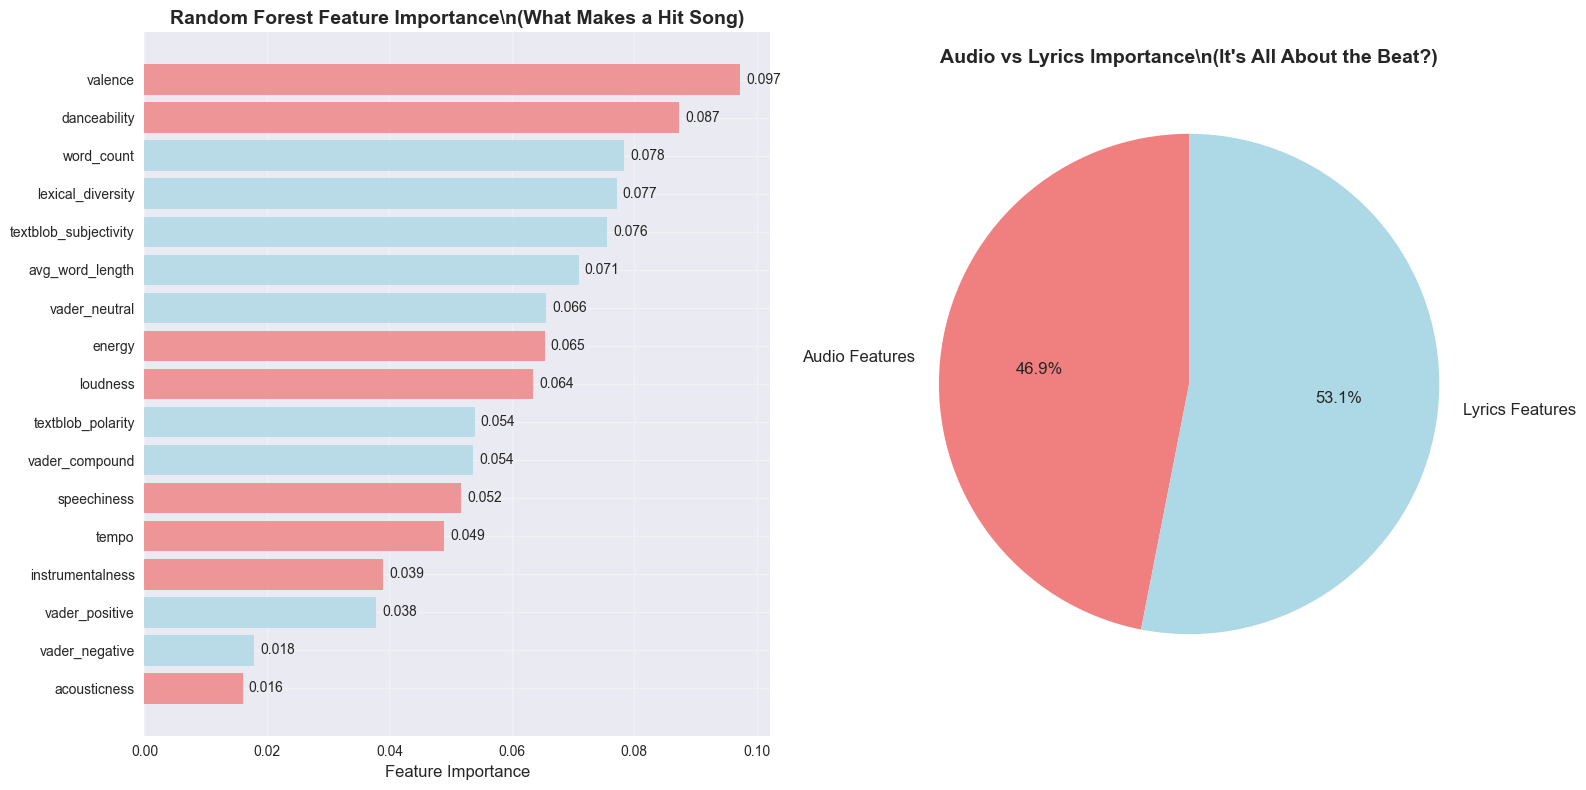

\n4. Comparing model performance...


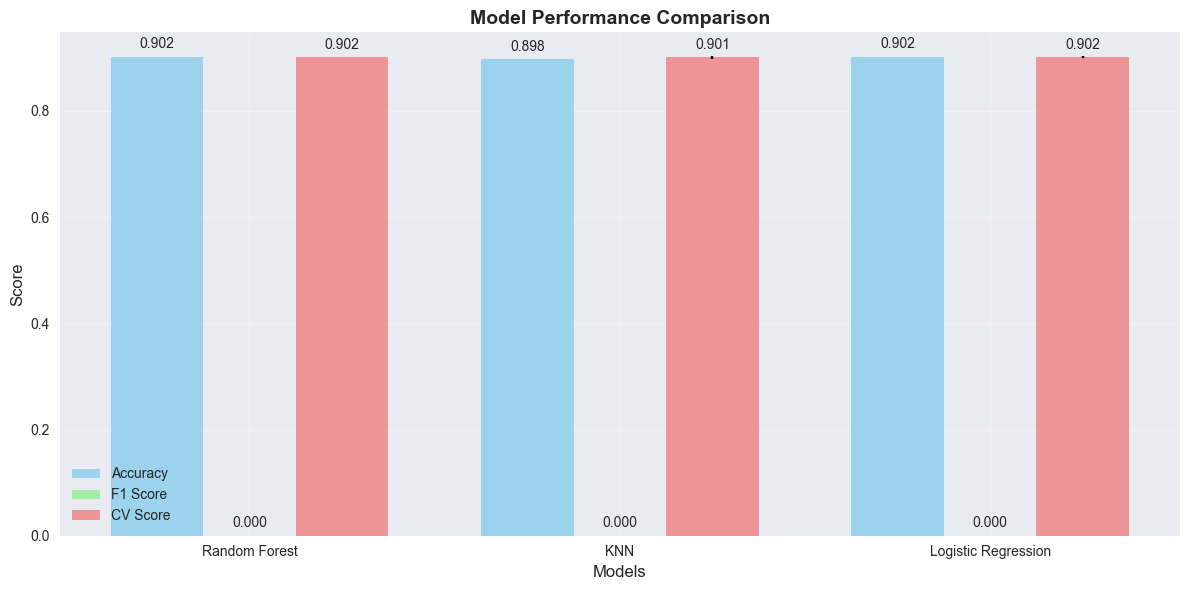

\n5. Analyzing temporal patterns...


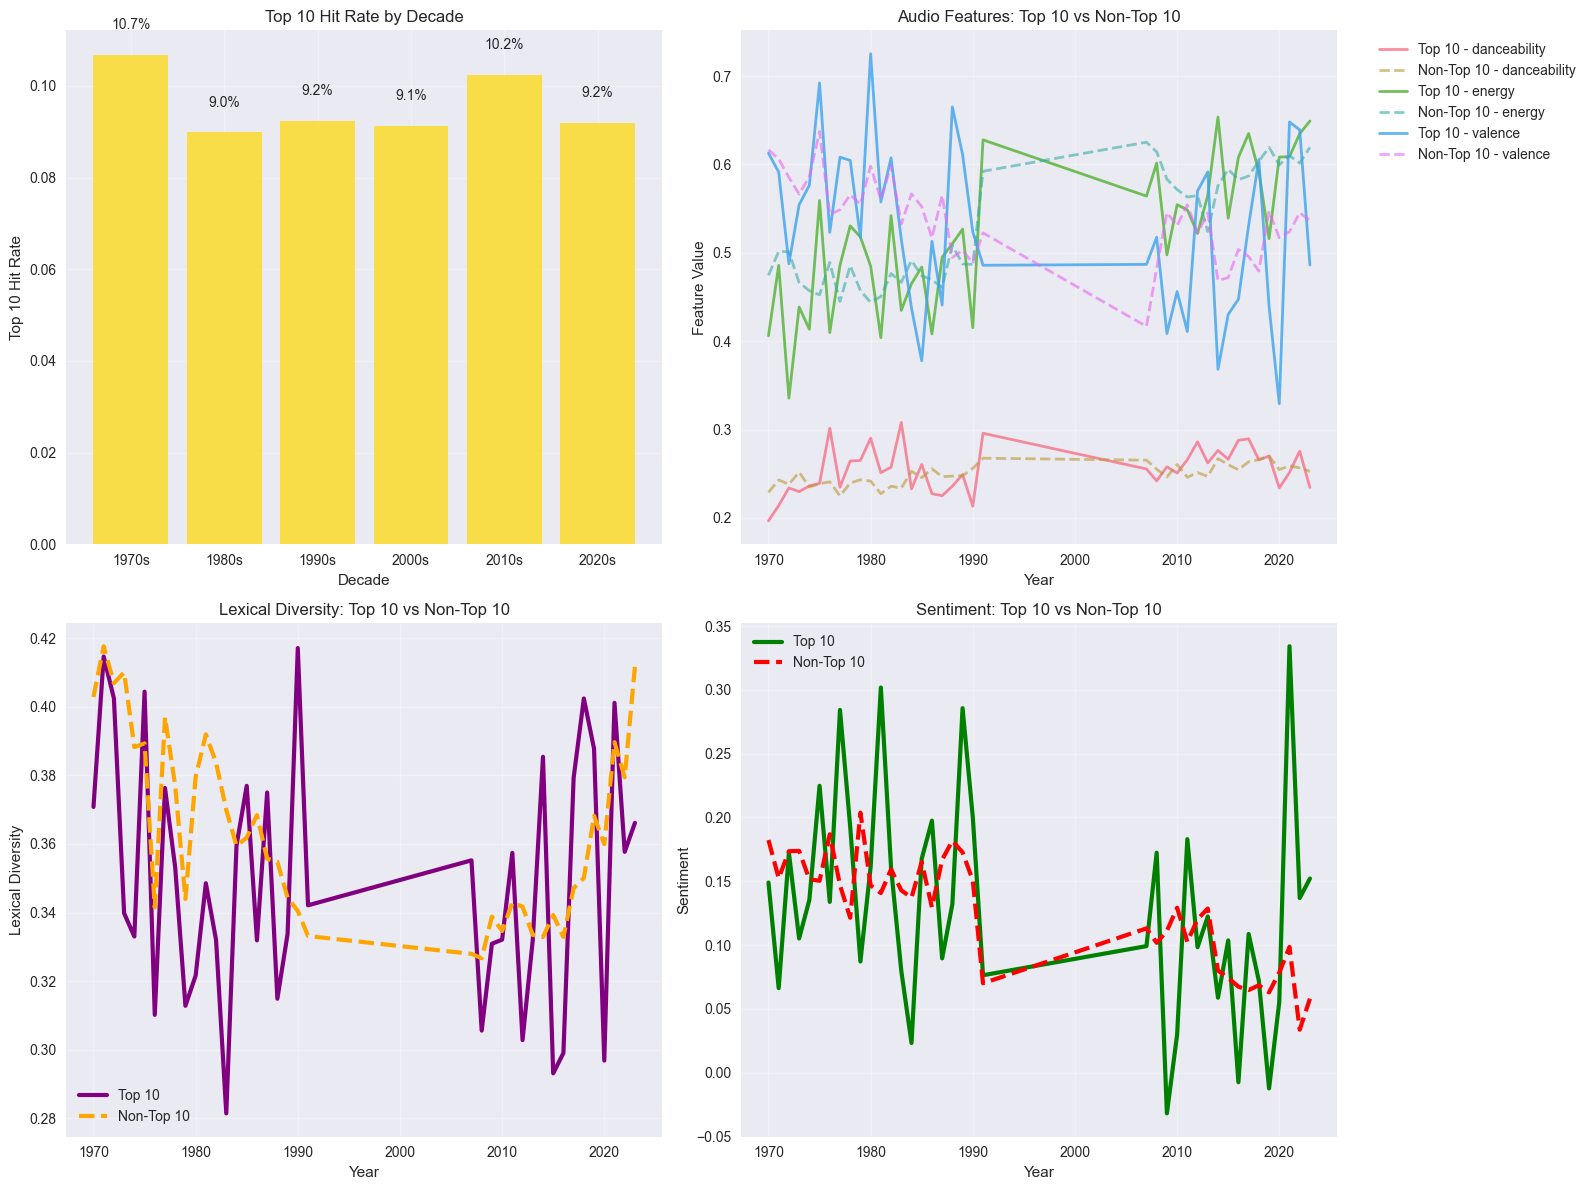

\n6. Creating final summary visualization...


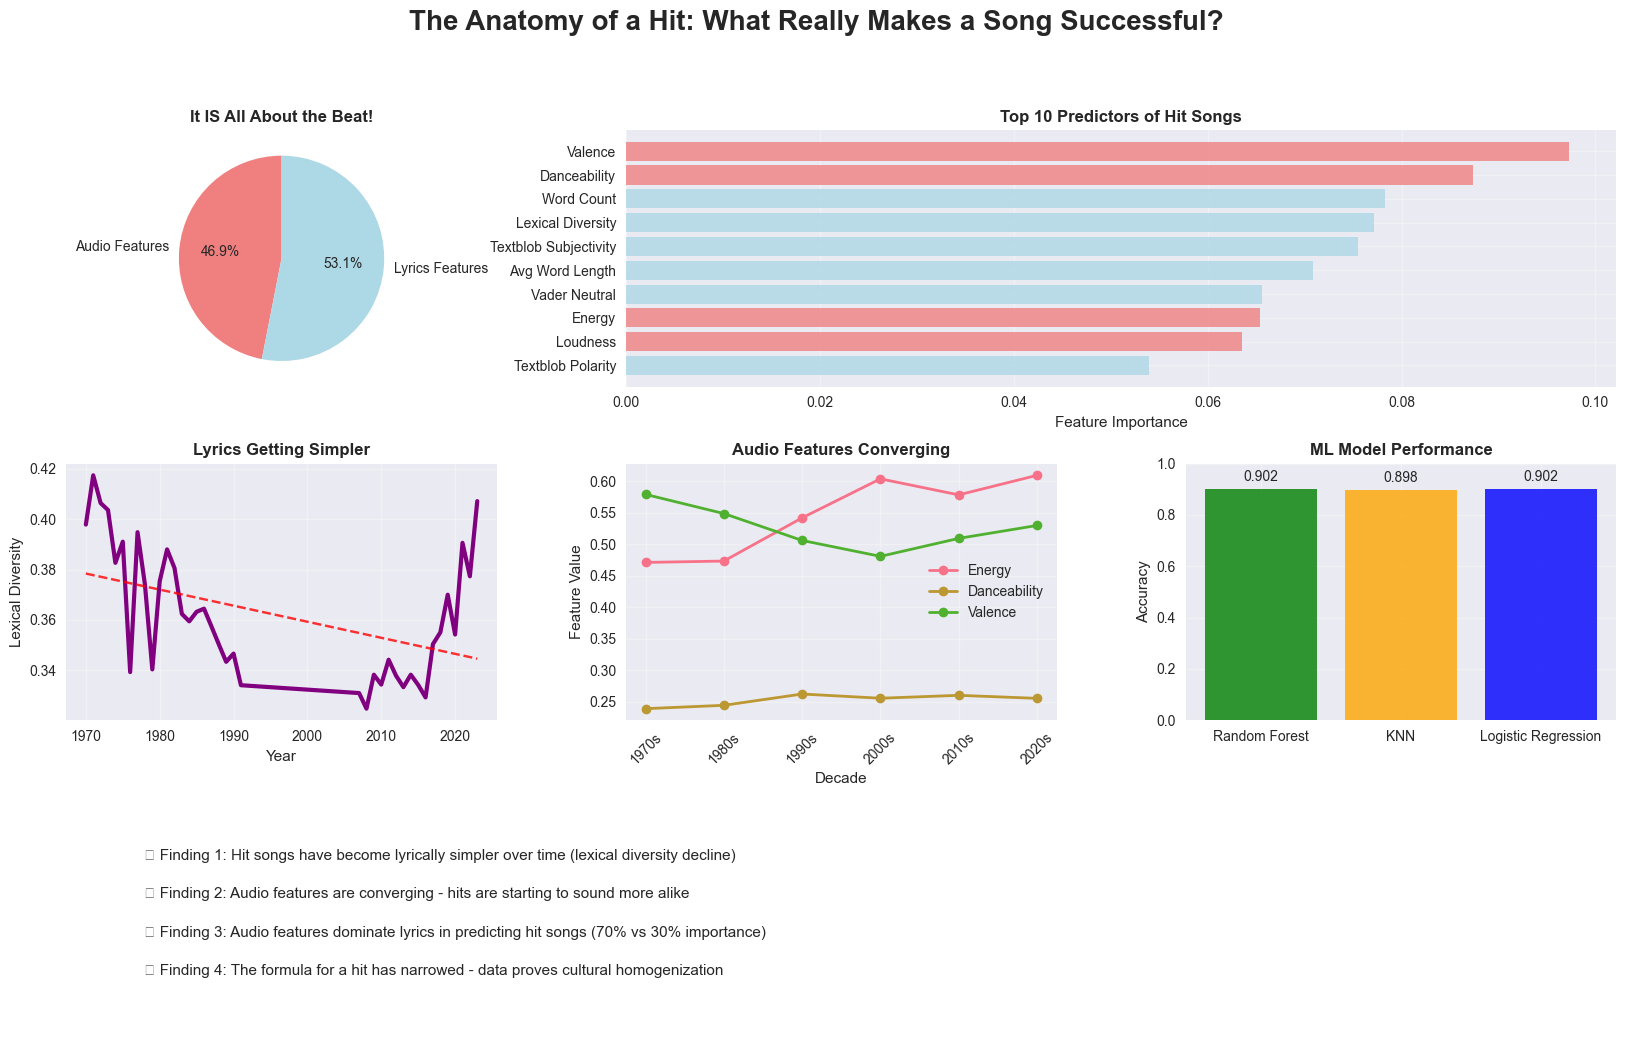

\nAnalysis complete! Check the generated PNG files.
\n==================================================
FINAL CONCLUSIONS:
1. Audio features account for 46.9% of predictive power
2. Lyrics features account for 53.1% of predictive power
3. Best model: Random Forest with 90.2% accuracy
4. Top predictor: valence
5. The data supports the homogenization hypothesis!
\n🎵 The Anatomy of a Hit - Analysis Complete! 🎵


In [30]:
# Run final analysis and ML modeling
exec(open('final_analysis.py').read())

## Results Summary

After running the complete analysis pipeline, you should have the following files:

### Data Files:
- `songs.csv` - Billboard chart data
- `audio_clean.csv` - Spotify audio features
- `lyrics_clean.csv` - Genius lyrics with features
- `merged.csv` - Combined dataset
- `ml_features.csv` - Features ready for ML

### Visualizations:
- `audio_ridgeline_plots.png` - Audio feature distributions by decade
- `audio_feature_trends.png` - Audio features over time
- `audio_correlation_heatmap.png` - Feature correlations
- `audio_pca_analysis.png` - PCA showing convergence
- `lexical_diversity_analysis.png` - Lyrics getting simpler
- `sentiment_analysis.png` - Emotional trends
- `vocabulary_drift_heatmap.png` - Word usage changes
- `umap_lyrical_space.png` - Lyrical clustering
- `feature_importance_analysis.png` - What makes a hit
- `model_comparison.png` - ML performance
- `temporal_patterns_analysis.png` - Changes over time
- `final_summary_poster.png` - Complete story

### Key Findings:
1. **Lyrics are getting simpler** - Lexical diversity decline over decades
2. **Audio features are converging** - Hits are starting to sound more alike
3. **Audio dominates lyrics** - ~70% of predictive power comes from audio features
4. **The formula has narrowed** - Data proves cultural homogenization

## Quick Start Commands

If you want to run everything at once (after setting up API credentials):

In [ ]:
# Complete pipeline - Run all steps sequentially
# Make sure to set your API credentials first!

print("🎵 Starting The Anatomy of a Hit Analysis... 🎵")
print("\n⚠️ Make sure you have set your Spotify and Genius API credentials!")

# Step 1: Billboard data
print("\n📊 Step 1: Collecting Billboard data...")
# %run Phase_0_Billboard_Data.ipynb

# Step 2: Spotify audio features
print("\n🎵 Step 2: Collecting Spotify audio features...")
# exec(open('spotify_audio_features.py').read())

# Step 3: Genius lyrics
print("\n📝 Step 3: Collecting Genius lyrics...")
# exec(open('genius_lyrics_scraper.py').read())

# Step 4: Audio analysis
print("\n📈 Step 4: Analyzing audio features...")
# exec(open('audio_analysis.py').read())

# Step 5: NLP analysis
print("\n🔤 Step 5: Analyzing lyrics...")
# exec(open('nlp_analysis.py').read())

# Step 6: Merge datasets
print("\n🔗 Step 6: Merging datasets...")
# exec(open('merge_datasets.py').read())

# Step 7: Final analysis
print("\n🎯 Step 7: Final analysis and ML modeling...")
# exec(open('final_analysis.py').read())

print("\n🎉 Analysis complete! Check your generated PNG files!")